In [1]:
# | Column                     | المعنى                                          
# | -------------------------- | ----------------------------------------------- 
# | **star_id**                | معرف النجم.                                     
# | **spectral_type**          | النوع الطيفي للنجم.                             
# | **stellar_radius_sr**      | نصف قطر النجم.                                   
# | **stellar_mass_sm**        | كتلة النجم.                                      
# | **stellar_teff_k**         | درجة حرارة سطح النجم (كلفن).                     
# | **stellar_log_g**          | الجاذبية السطحية للنجم.                          
# | **stellar_luminosity**     | لمعان النجم.                                     
# | **stellar_metallicity**    | نسبة العناصر الثقيلة (المعدنية) في النجم.        
# | **stellar_rot_period_d**   | فترة دوران النجم بالأيام.                        
# | **stellar_noise_ppm**      | الضوضاء في قياسات سطوع النجم.                    
# | **orbital_period_d**       | الفترة المدارية للكوكب بالأيام.                  
# | **planet_radius_re**       | نصف قطر الكوكب.                                  
# | **semi_major_axis_au**     | متوسط بعد الكوكب عن النجم.                       
# | **eccentricity**           | درجة انحراف المدار عن الدائرة.                   
# | **inclination_deg**        | زاوية ميل مدار الكوكب.                           
# | **impact_parameter**       | مسافة مرور الكوكب أمام مركز النجم أثناء العبور.  
# | **transit_depth_ppm**      | مقدار انخفاض سطوع النجم أثناء عبور الكوكب.      
# | **transit_duration_hr**    | مدة عبور الكوكب أمام النجم بالساعات.            
# | **n_transits_observed**    | عدد مرات رصد عبور الكوكب.                       
# | **orbital_velocity_kms**   | السرعة المدارية للكوكب.                         
# | **transit_snr**            | نسبة الإشارة إلى الضوضاء أثناء العبور.          
# | **planet_eq_temp_k**       | درجة حرارة توازن الكوكب.                        
# | **flux_variability_index** | مؤشر تغير سطوع النجم.                           
# | **log_period**             | اللوغاريتم للفترة المدارية.                     
# | **log_snr**                | اللوغاريتم لنسبة الإشارة إلى الضوضاء.           
# | **label**                  | هل يوجد كوكب خارجي حول النجم أم لا (0 أو 1).    


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
import pandas as pd

train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')



In [4]:
test_df.head()


,star_id,spectral_type,stellar_radius_sr,stellar_mass_sm,stellar_teff_k,stellar_log_g,stellar_luminosity,stellar_metallicity,stellar_rot_period_d,stellar_noise_ppm,...,impact_parameter,transit_depth_ppm,transit_duration_hr,n_transits_observed,orbital_velocity_kms,transit_snr,planet_eq_temp_k,flux_variability_index,log_period,log_snr
0,STR-011368,G,0.964966,1.135460,6433.946539,4.584133,1.304133,NaN,30.25,214.06,...,2.063365,39.020226,0.677786,0.0,NaN,1.013957,NaN,0.1823,0.0000,0.7001
1,STR-005379,G,0.993492,0.965950,5745.683490,4.505384,0.835463,0.029,14.68,254.52,...,1.309884,3.828211,0.904570,0.0,NaN,0.362411,NaN,0.0150,0.0000,0.3093
2,STR-004743,M,0.372823,0.406993,2771.792229,4.844474,0.007724,0.040,23.73,152.11,...,6.975400,23914.420430,0.000000,7.0,37.306,410.016525,143.5,157.2179,4.2879,6.0186
3,STR-007357,M,0.293140,0.348852,3263.246032,5.157534,0.009050,-0.160,20.43,190.22,...,1.312543,11.366134,0.503267,0.0,NaN,0.571821,NaN,0.0598,0.0000,0.4522
4,STR-010554,K,0.602961,0.798362,4096.670693,4.785904,0.094093,-0.362,24.09,226.63,...,0.720647,6398.834558,9.432706,0.0,NaN,13.974202,NaN,28.2347,3.5548,2.7063


In [5]:
train_df['label'].value_counts()

label
0    6877
1    2123
Name: count, dtype: int64

In [6]:
train_df.shape

(9000, 27)

In [7]:
train_df.describe()

,stellar_radius_sr,stellar_mass_sm,stellar_teff_k,stellar_log_g,stellar_luminosity,stellar_metallicity,stellar_rot_period_d,stellar_noise_ppm,label,planet_radius_re,...,impact_parameter,transit_depth_ppm,transit_duration_hr,n_transits_observed,orbital_velocity_kms,transit_snr,planet_eq_temp_k,flux_variability_index,log_period,log_snr
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,8721.000000,8757.000000,9000.000000,9000.000000,2123.000000,...,9000.000000,9000.000000,8732.000000,9000.000000,2123.000000,9000.000000,2047.000000,9000.000000,9000.000000,9000.000000
mean,0.999461,1.030182,5498.874040,4.471140,44.938949,-0.002093,26.109717,228.888308,0.235889,4.150818,...,1.822924,1271.836018,1.115910,25.598778,95.256447,39.083328,787.999805,6.171527,0.752995,1.333866
std,0.531128,0.832256,1956.484447,0.209796,530.611928,0.252395,9.833125,63.280785,0.424577,3.116753,...,0.958406,5910.657736,2.123687,72.107558,34.270890,326.596278,425.203197,30.899012,1.295415,1.571583
min,0.103966,0.190543,2566.991923,3.447926,0.001036,-0.855000,1.020000,128.470000,0.000000,0.500000,...,0.000300,0.007624,0.000000,0.000000,24.741000,0.000440,113.100000,0.000000,0.000000,0.000400
25%,0.787760,0.747421,4490.243879,4.341757,0.231391,-0.170000,19.270000,197.295000,0.000000,2.031000,...,1.260603,13.313970,0.134684,0.000000,70.702000,0.430503,525.850000,0.058800,0.000000,0.358050
50%,0.948049,0.942735,5574.502768,4.457950,0.802056,0.000000,26.220000,219.075000,0.000000,3.301000,...,1.827981,29.899329,0.386461,0.000000,89.740000,0.967126,713.400000,0.134850,0.000000,0.676600
75%,1.106591,1.092359,5950.482188,4.581465,1.253591,0.169000,32.770000,244.930000,0.000000,5.191000,...,2.419898,177.485147,0.831170,0.000000,113.537500,3.979311,960.100000,0.772925,1.569125,1.605300
max,7.131389,12.955883,30294.305462,6.000948,13985.665382,0.800000,60.460000,1049.080000,1.000000,25.000000,...,25.177100,250648.698840,21.150640,500.000000,285.334000,15563.216761,7459.100000,1138.536000,6.216600,9.652700


In [8]:
train_df.isnull().sum()

star_id                      0
spectral_type                0
stellar_radius_sr            0
stellar_mass_sm              0
stellar_teff_k               0
stellar_log_g                0
stellar_luminosity           0
stellar_metallicity        279
stellar_rot_period_d       243
stellar_noise_ppm            0
label                        0
planet_radius_re          6877
rp_rs_ratio               6877
orbital_period_d          6481
semi_major_au             6877
eccentricity              6942
inclination_deg           6877
impact_parameter             0
transit_depth_ppm            0
transit_duration_hr        268
n_transits_observed          0
orbital_velocity_kms      6877
transit_snr                  0
planet_eq_temp_k          6953
flux_variability_index       0
log_period                   0
log_snr                      0
dtype: int64

In [9]:
train_df.duplicated().sum()

np.int64(0)

In [10]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   star_id                 9000 non-null   object 
 1   spectral_type           9000 non-null   object 
 2   stellar_radius_sr       9000 non-null   float64
 3   stellar_mass_sm         9000 non-null   float64
 4   stellar_teff_k          9000 non-null   float64
 5   stellar_log_g           9000 non-null   float64
 6   stellar_luminosity      9000 non-null   float64
 7   stellar_metallicity     8721 non-null   float64
 8   stellar_rot_period_d    8757 non-null   float64
 9   stellar_noise_ppm       9000 non-null   float64
 10  label                   9000 non-null   int64  
 11  planet_radius_re        2123 non-null   float64
 12  rp_rs_ratio             2123 non-null   float64
 13  orbital_period_d        2519 non-null   float64
 14  semi_major_au           2123 non-null   

**data_Visualization**

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [12]:
train_df['label'].value_counts()

label
0    6877
1    2123
Name: count, dtype: int64

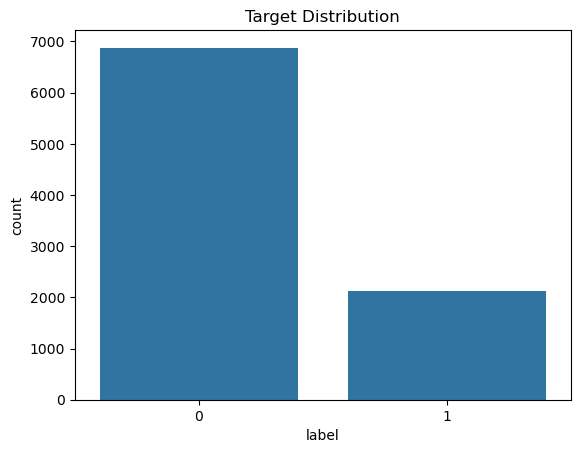

In [13]:
sns.countplot(data=train_df, x='label')
plt.title("Target Distribution")
plt.show()

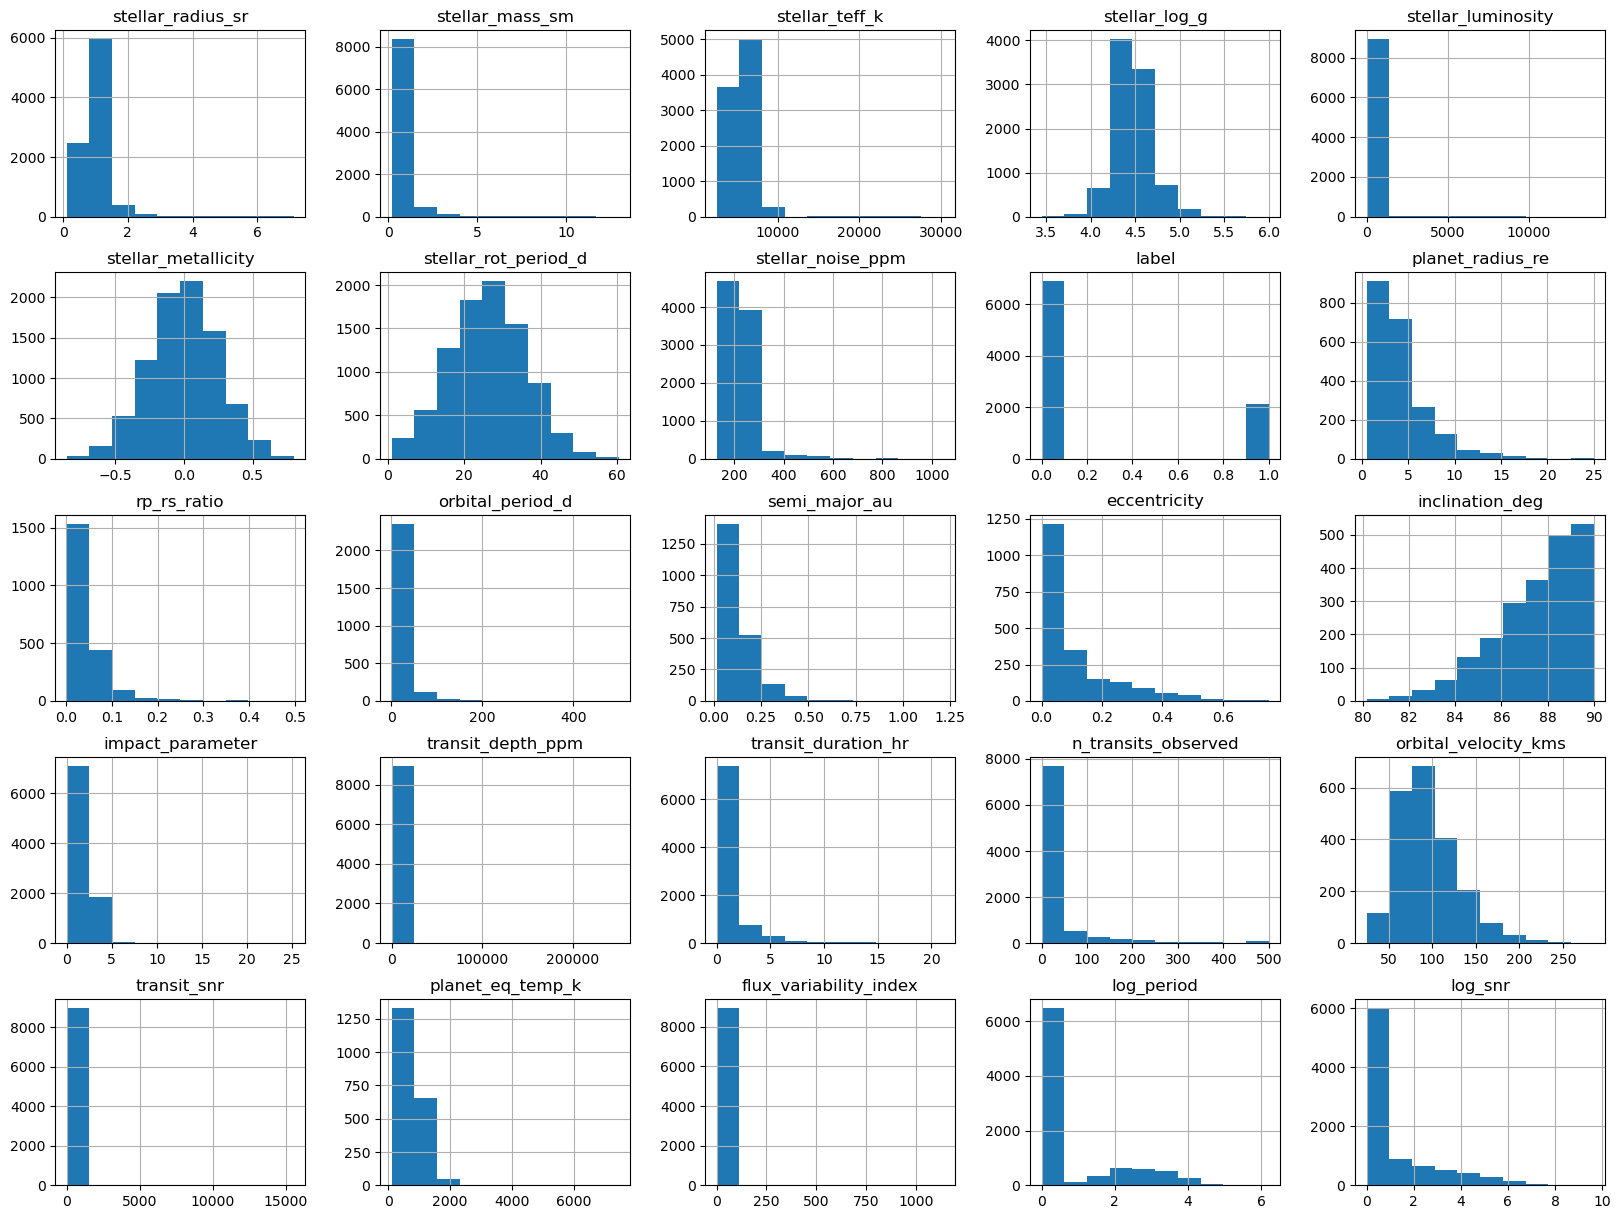

In [14]:
train_df.hist(figsize=(20,15))
plt.show()

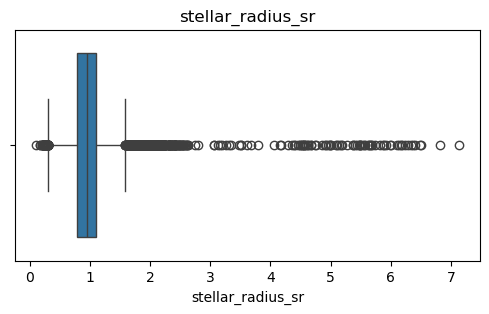

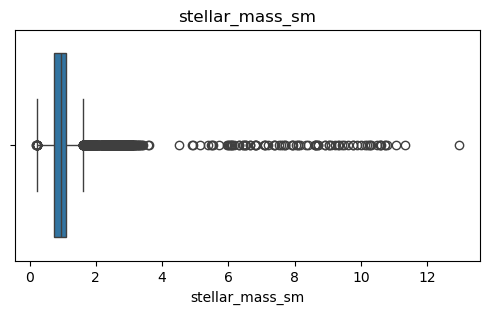

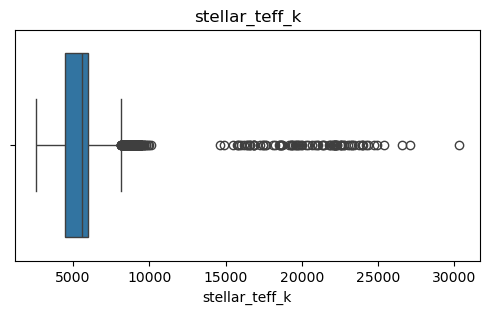

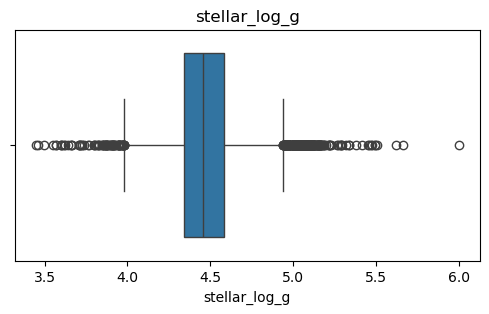

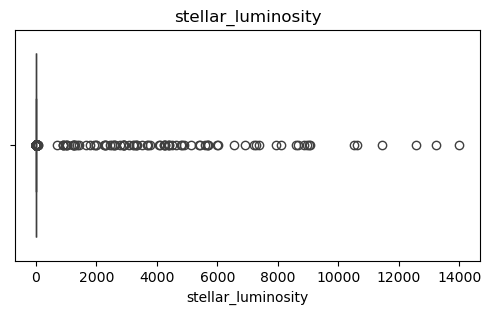

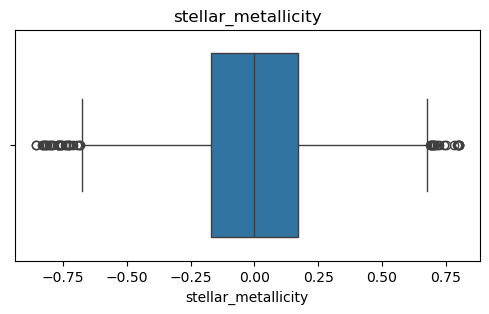

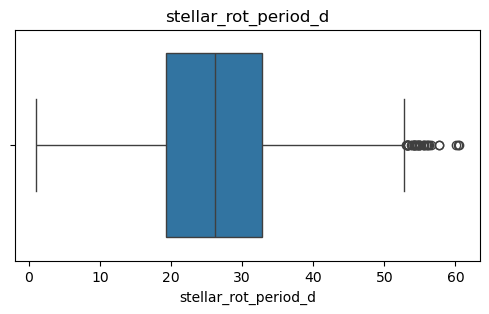

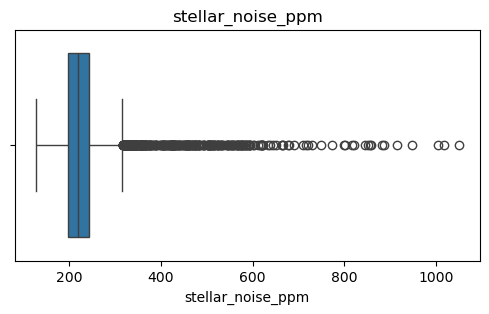

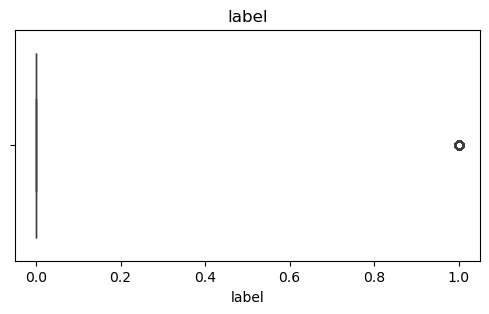

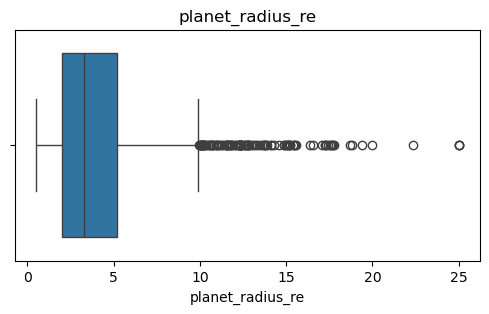

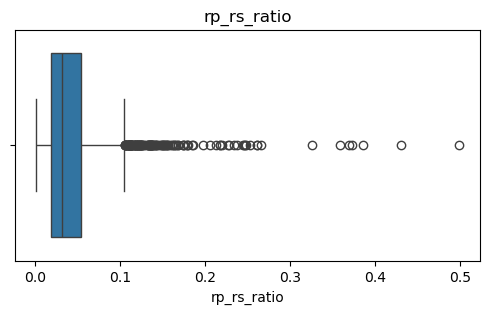

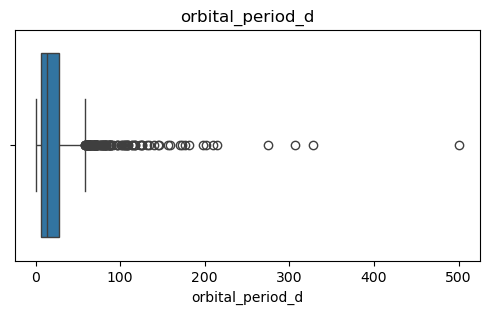

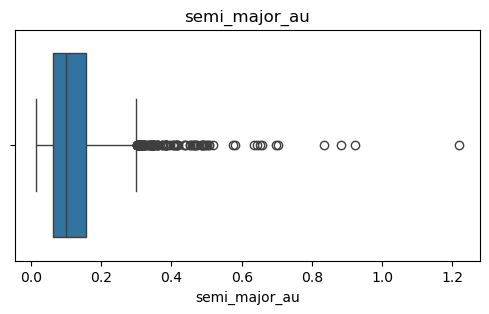

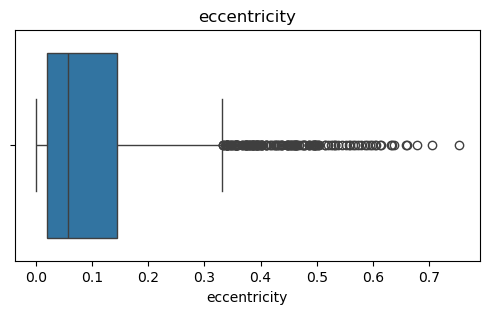

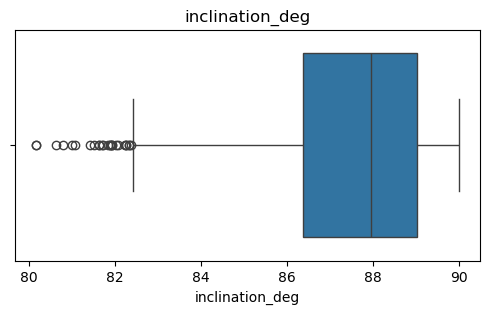

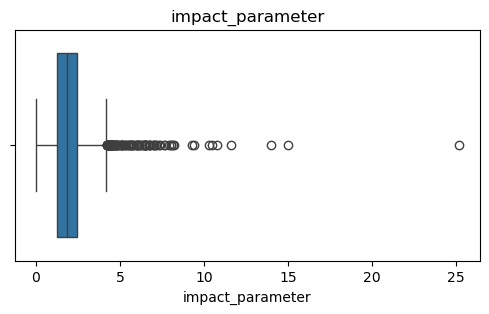

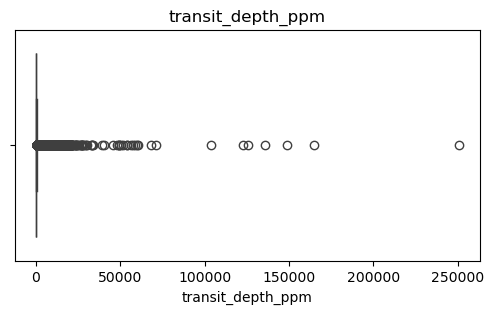

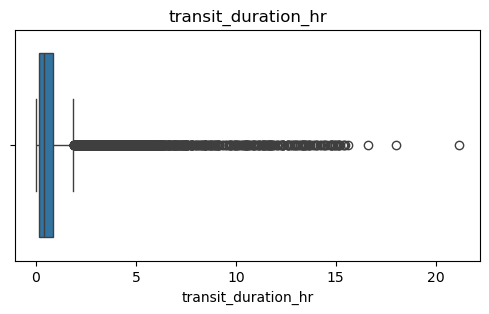

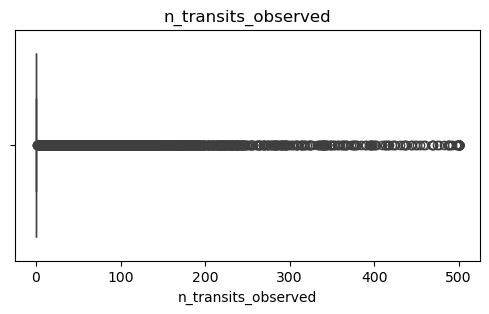

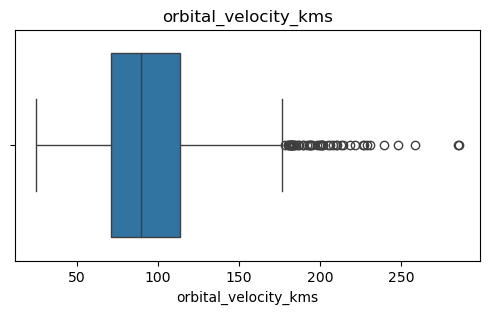

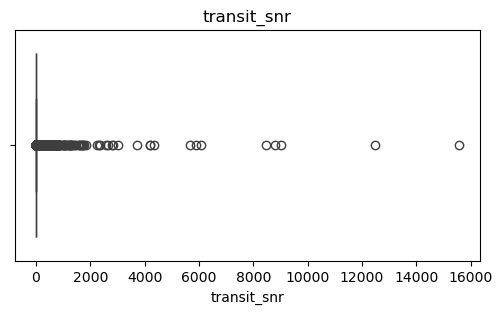

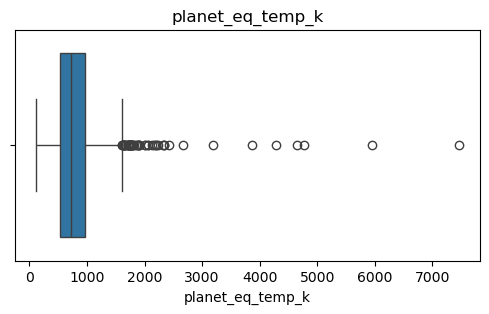

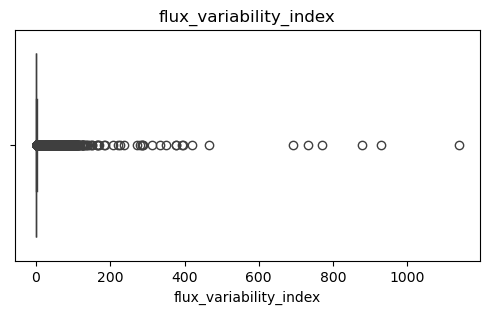

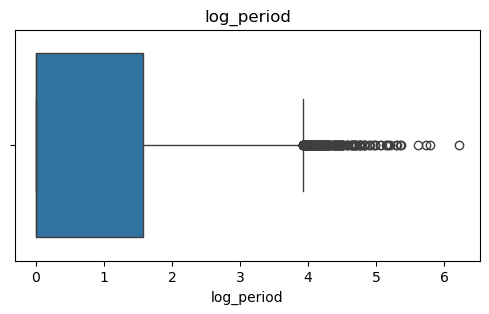

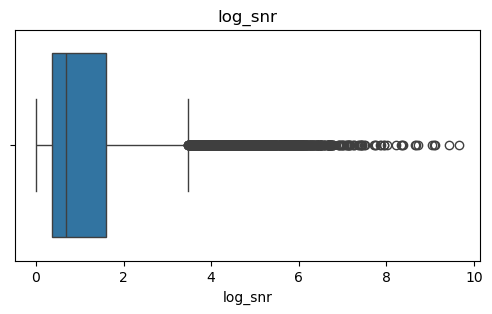

In [15]:
numeric_cols = train_df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=train_df[col])
    plt.title(col)
    plt.show()

In [16]:
cols = [
    'transit_depth_ppm',
    'transit_snr',
    'flux_variability_index'
]

for col in cols:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    train_df[col] = train_df[col].clip(lower, upper)

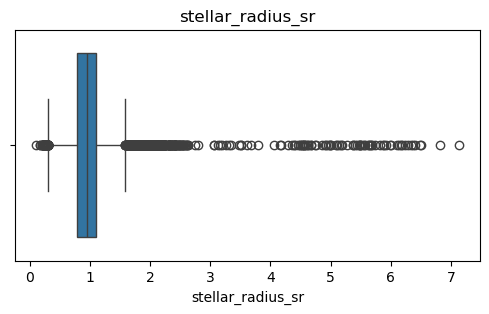

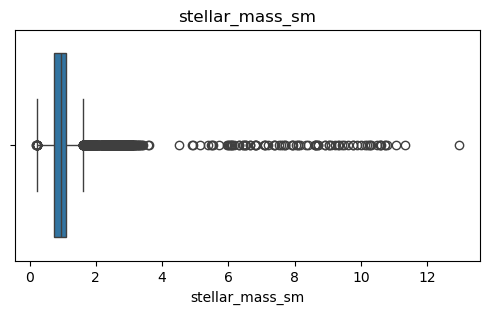

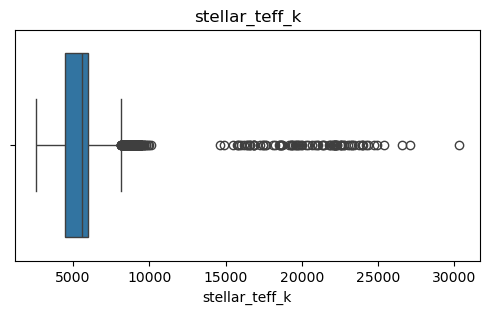

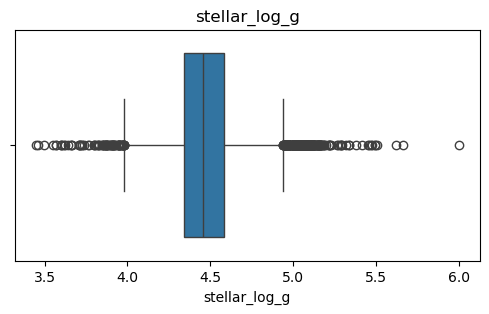

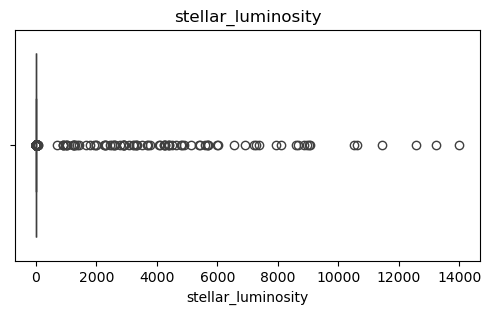

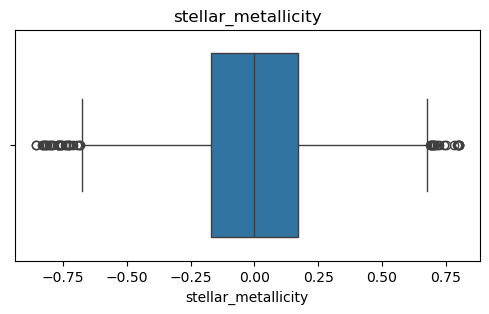

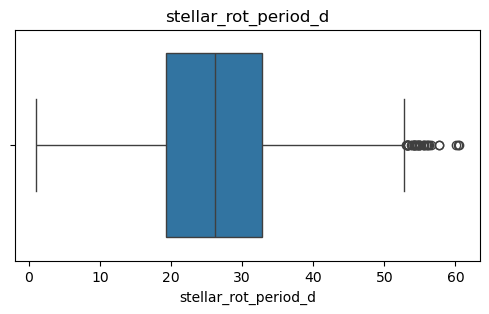

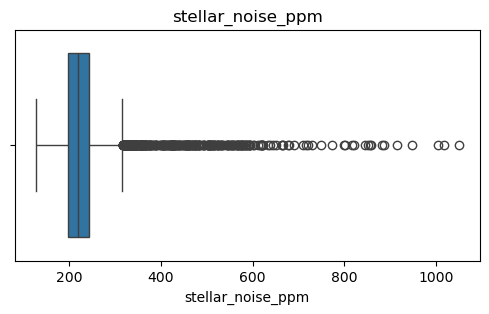

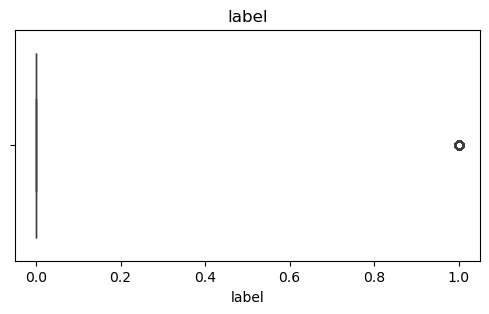

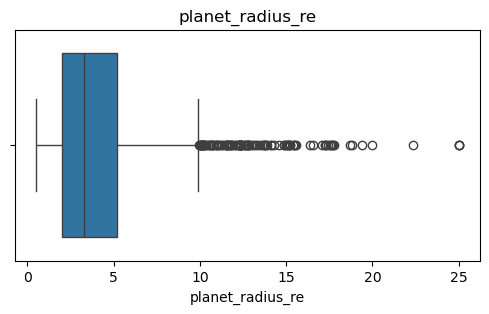

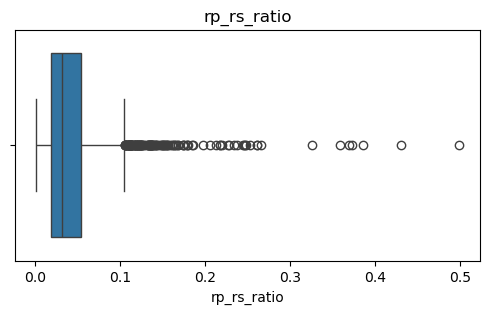

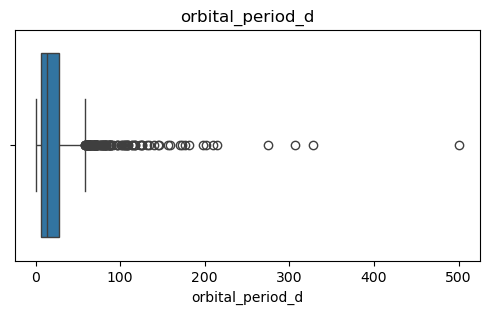

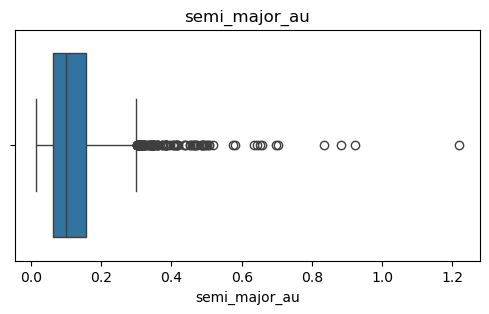

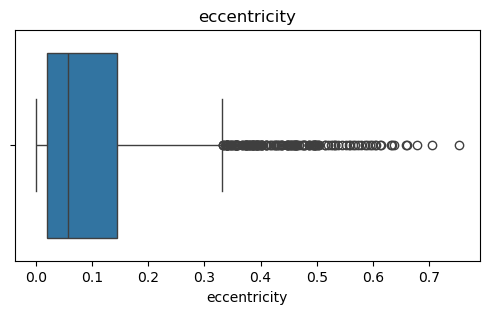

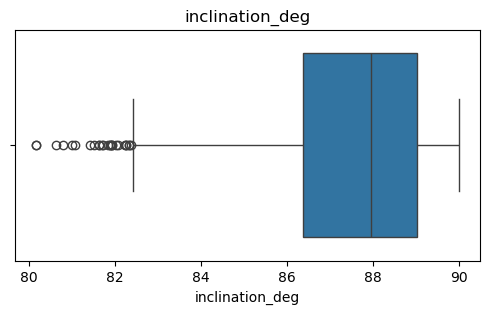

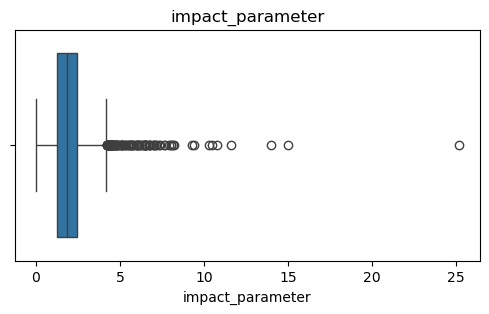

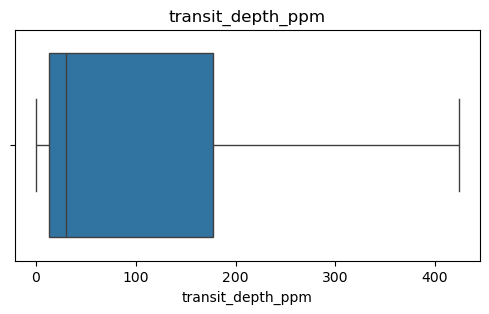

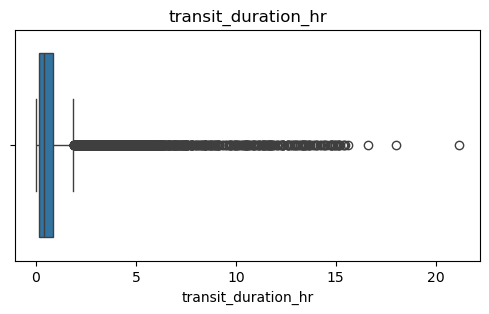

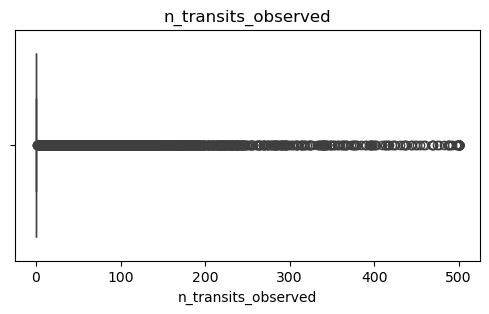

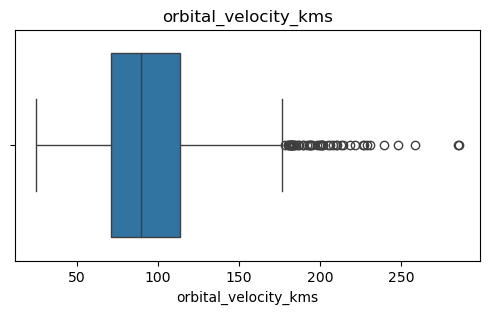

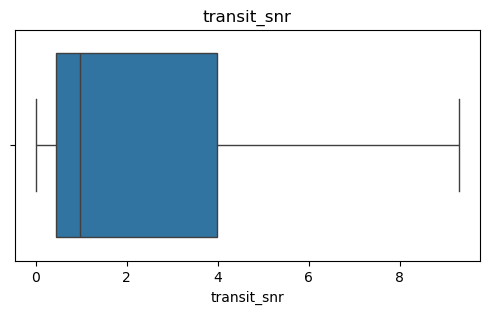

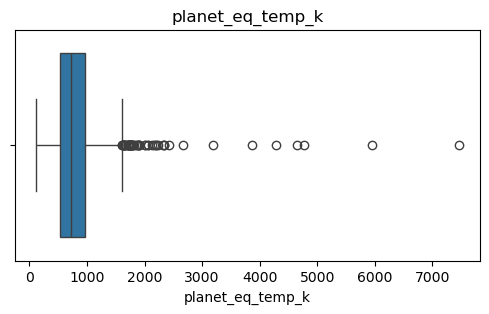

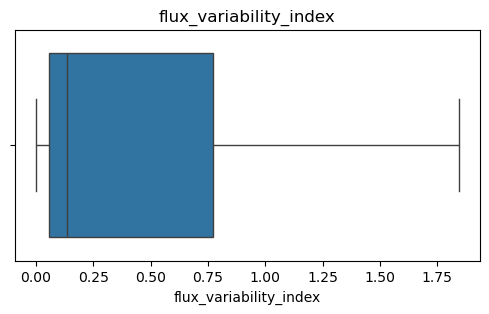

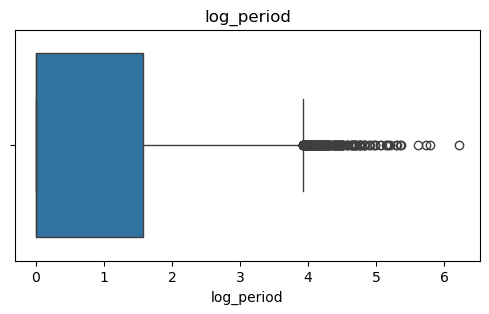

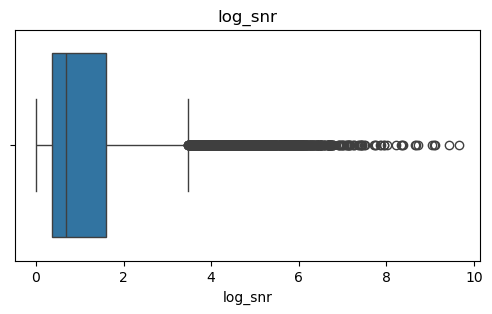

In [17]:
numeric_cols = train_df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=train_df[col])
    plt.title(col)
    plt.show()

In [18]:
train_df['label'].value_counts()

label
0    6877
1    2123
Name: count, dtype: int64

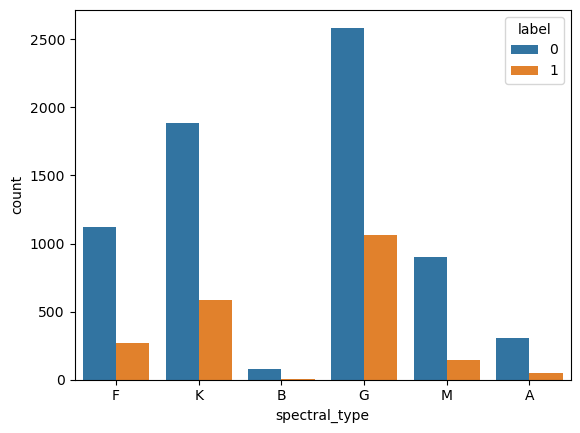

In [19]:
sns.countplot(data=train_df, x='spectral_type', hue='label')
plt.show()

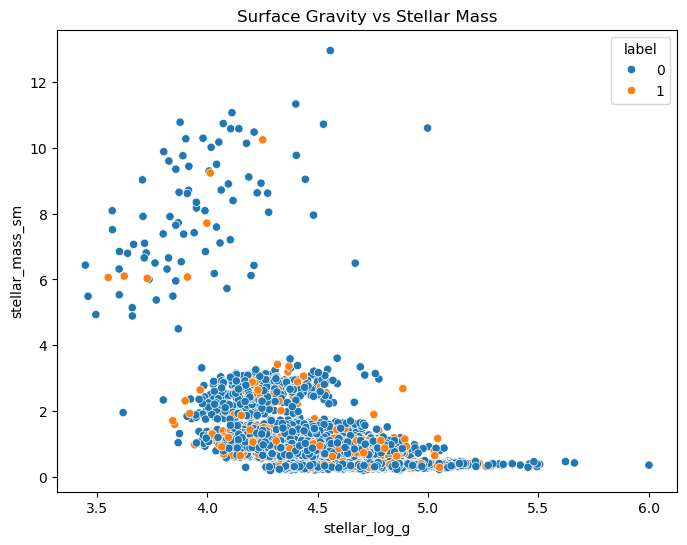

In [20]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=train_df,
    x='stellar_log_g',
    y='stellar_mass_sm',
    hue='label'
)

plt.title("Surface Gravity vs Stellar Mass")
plt.show()

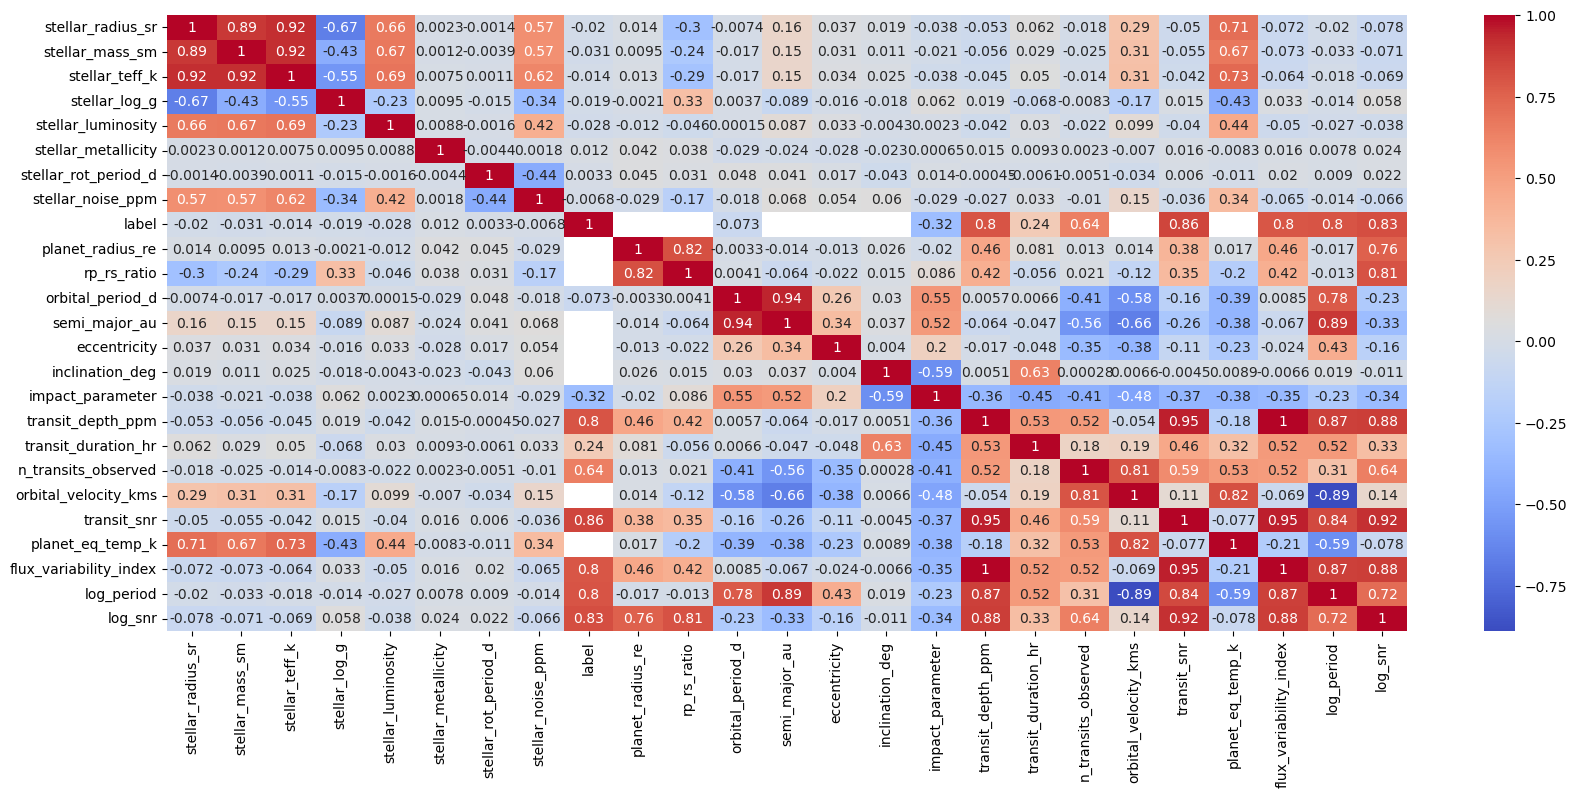

In [21]:
numeric_df = train_df.select_dtypes(include='number')

plt.figure(figsize=(20,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

**Data_Cleaning**

In [22]:
train_df = train_df.drop('star_id', axis=1)
test_df = test_df.drop('star_id', axis=1)

In [23]:
type(train_df)

pandas.core.frame.DataFrame

In [24]:
test_df.isnull().sum()

spectral_type                0
stellar_radius_sr            0
stellar_mass_sm              0
stellar_teff_k               0
stellar_log_g                0
stellar_luminosity           0
stellar_metallicity         81
stellar_rot_period_d       117
stellar_noise_ppm            0
planet_radius_re          2293
rp_rs_ratio               2293
orbital_period_d          2139
semi_major_au             2293
eccentricity              2313
inclination_deg           2293
impact_parameter             0
transit_depth_ppm            0
transit_duration_hr         92
n_transits_observed          0
orbital_velocity_kms      2293
transit_snr                  0
planet_eq_temp_k          2315
flux_variability_index       0
log_period                   0
log_snr                      0
dtype: int64

In [25]:
numeric_cols = train_df.select_dtypes(include='number').columns.drop('label')

mean_values = train_df[numeric_cols].mean()

train_df[numeric_cols] = train_df[numeric_cols].fillna(mean_values)
test_df[numeric_cols] = test_df[numeric_cols].fillna(mean_values)

In [26]:
test_df.isnull().sum()

spectral_type             0
stellar_radius_sr         0
stellar_mass_sm           0
stellar_teff_k            0
stellar_log_g             0
stellar_luminosity        0
stellar_metallicity       0
stellar_rot_period_d      0
stellar_noise_ppm         0
planet_radius_re          0
rp_rs_ratio               0
orbital_period_d          0
semi_major_au             0
eccentricity              0
inclination_deg           0
impact_parameter          0
transit_depth_ppm         0
transit_duration_hr       0
n_transits_observed       0
orbital_velocity_kms      0
transit_snr               0
planet_eq_temp_k          0
flux_variability_index    0
log_period                0
log_snr                   0
dtype: int64

**Encoding**

In [27]:
print(sorted(train_df['spectral_type'].unique()))
print(sorted(test_df['spectral_type'].unique()))

['A', 'B', 'F', 'G', 'K', 'M']
['A', 'B', 'F', 'G', 'K', 'M']


In [28]:
print(train_df['spectral_type'].head())
print(test_df['spectral_type'].head())
print(train_df['spectral_type'].dtype)
print(test_df['spectral_type'].dtype)

0    F
1    K
2    K
3    B
4    G
Name: spectral_type, dtype: object
0    G
1    G
2    M
3    M
4    K
Name: spectral_type, dtype: object
object
object


In [29]:
set(test_df['spectral_type']) - set(train_df['spectral_type'])

set()

In [30]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

all_spectral = pd.concat([
    train_df['spectral_type'],
    test_df['spectral_type']
])

le.fit(all_spectral)

train_df['spectral_type'] = le.transform(train_df['spectral_type'])
test_df['spectral_type'] = le.transform(test_df['spectral_type'])

In [31]:
test_df

,spectral_type,stellar_radius_sr,stellar_mass_sm,stellar_teff_k,stellar_log_g,stellar_luminosity,stellar_metallicity,stellar_rot_period_d,stellar_noise_ppm,planet_radius_re,...,impact_parameter,transit_depth_ppm,transit_duration_hr,n_transits_observed,orbital_velocity_kms,transit_snr,planet_eq_temp_k,flux_variability_index,log_period,log_snr
0,3,0.964966,1.135460,6433.946539,4.584133,1.304133,-0.002093,30.25,214.06,4.150818,...,2.063365,39.020226,0.677786,0.0,95.256447,1.013957,787.999805,0.1823,0.0000,0.7001
1,3,0.993492,0.965950,5745.683490,4.505384,0.835463,0.029000,14.68,254.52,4.150818,...,1.309884,3.828211,0.904570,0.0,95.256447,0.362411,787.999805,0.0150,0.0000,0.3093
2,5,0.372823,0.406993,2771.792229,4.844474,0.007724,0.040000,23.73,152.11,6.574000,...,6.975400,23914.420430,0.000000,7.0,37.306000,410.016525,143.500000,157.2179,4.2879,6.0186
3,5,0.293140,0.348852,3263.246032,5.157534,0.009050,-0.160000,20.43,190.22,4.150818,...,1.312543,11.366134,0.503267,0.0,95.256447,0.571821,787.999805,0.0598,0.0000,0.4522
4,4,0.602961,0.798362,4096.670693,4.785904,0.094093,-0.362000,24.09,226.63,4.150818,...,0.720647,6398.834558,9.432706,0.0,95.256447,13.974202,787.999805,28.2347,3.5548,2.7063
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0,1.654910,2.594649,8328.164775,4.248114,12.102480,-0.194000,31.48,270.34,1.294000,...,0.078000,45.098133,1.115910,119.0,162.314000,1.748721,1553.900000,0.1668,1.9840,1.0111
2996,2,1.583850,1.200412,6340.164710,4.127479,3.553698,0.284000,15.37,270.29,4.150818,...,1.247478,23.203469,0.387205,0.0,95.256447,1.466222,787.999805,0.0858,0.0000,0.9027
2997,0,1.966783,2.696983,8881.317082,4.361201,21.777636,0.090000,34.65,257.14,4.150818,...,2.476029,6.833763,0.257441,0.0,95.256447,0.175637,787.999805,0.0266,0.0000,0.1618
2998,4,0.672321,0.884313,4415.575401,4.757423,0.149521,0.015000,28.02,186.98,4.150818,...,1.372518,40.171279,0.026260,0.0,95.256447,1.300626,787.999805,0.2148,0.0000,0.8332


**Scaling**

In [32]:
cols_to_scale = [
    'stellar_teff_k',
    'stellar_luminosity',
    'stellar_noise_ppm',
    'transit_depth_ppm',
    'transit_duration_hr',
    'orbital_velocity_kms',
    'transit_snr',
    'planet_eq_temp_k',
    'flux_variability_index',
    'log_snr',
    "n_transits_observed",
    'stellar_rot_period_d'
]

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_df[cols_to_scale] = scaler.fit_transform(train_df[cols_to_scale])

test_df[cols_to_scale] = scaler.transform(test_df[cols_to_scale])

In [34]:
train_df

,spectral_type,stellar_radius_sr,stellar_mass_sm,stellar_teff_k,stellar_log_g,stellar_luminosity,stellar_metallicity,stellar_rot_period_d,stellar_noise_ppm,label,...,impact_parameter,transit_depth_ppm,transit_duration_hr,n_transits_observed,orbital_velocity_kms,transit_snr,planet_eq_temp_k,flux_variability_index,log_period,log_snr
0,2,1.327806,1.398391,0.722370,4.323038,-0.077889,-0.178,-0.519616,0.344068,0,...,2.183038,-0.587642,-0.459245,-0.355028,-1.707943e-15,-0.586503,1.121533e-15,-0.604531,0.0000,-0.499693
1,4,0.912461,0.708236,-0.493258,4.352924,-0.084135,-0.067,-0.998020,0.115866,0,...,1.326354,1.809341,5.961054,-0.355028,-1.707943e-15,0.476496,1.121533e-15,1.813442,3.5789,0.237503
2,4,0.684165,0.716614,-0.527636,4.652811,-0.084422,0.083,1.385751,-1.053274,1,...,0.539900,1.809341,0.731816,0.421633,-9.329091e-01,1.822565,-1.401831e+00,1.813442,2.6701,2.630192
3,1,4.403350,9.499783,8.509435,4.042372,8.170170,-0.056,-1.088752,6.106169,0,...,1.326998,-0.601090,-0.522890,-0.355028,-1.707943e-15,-0.437242,1.121533e-15,-0.684270,0.0000,-0.329410
4,3,0.927414,0.974574,0.076019,4.606604,-0.083277,0.194,-1.718720,0.627108,1,...,0.479000,1.274436,0.000000,0.282943,9.025685e-01,1.343561,2.555073e-01,0.986516,2.1764,0.520354
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8995,5,0.414126,0.307948,-1.132276,4.758766,-0.084660,0.039,0.907347,-1.331257,0,...,2.471450,-0.314743,-0.384730,-0.355028,-1.707943e-15,-0.783011,1.121533e-15,-0.076987,0.0000,-0.828934
8996,3,1.057576,0.882938,0.070485,4.333066,-0.082737,-0.274,-1.137211,0.470180,0,...,2.640814,-0.374794,-0.385007,-0.355028,-1.707943e-15,-0.738814,1.121533e-15,-0.418566,0.0000,-0.738638
8997,4,0.726660,0.729972,-0.412064,4.708886,-0.084285,0.096,1.703312,-0.739733,1,...,1.629500,1.809341,-0.533492,-0.244076,-3.024262e+00,1.822565,-2.437174e+00,1.813442,4.4048,0.970626
8998,4,0.913539,0.703584,-0.509182,4.294045,-0.084106,-0.115,-0.049461,-0.463963,0,...,2.691537,-0.569399,-0.531687,-0.355028,-1.707943e-15,-0.531014,1.121533e-15,-0.551142,0.0000,-0.430969


In [35]:
train_df['label'].unique()

array([0, 1])

**Train_test_split**

In [36]:
from sklearn.model_selection import train_test_split
x = train_df.drop('label', axis=1)
y = train_df['label']

x_train, x_test, y_train, y_test = train_test_split(
    x,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Models**

In [37]:
pip install xgboost

  Using cached xgboost-3.3.0-py3-none-win_amd64.whl.metadata (2.0 kB)
Using cached xgboost-3.3.0-py3-none-win_amd64.whl (69.5 MB)
Note: you may need to restart the kernel to use updated packages.


In [38]:
from sklearn.metrics import accuracy_score, classification_report, f1_score, recall_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier
)
from xgboost import XGBClassifier
from sklearn.ensemble import ExtraTreesClassifier



In [39]:
models = {

    "KNN": KNeighborsClassifier(),

    "Logistic Regression": LogisticRegression(
        max_iter=500,
        random_state=42
    ),

    "Naive Bayes": GaussianNB(),

    "SVM": SVC(
        probability=True
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Bagging": BaggingClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200,
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    )
}

In [40]:
results = []

for name, model in models.items():

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    results.append([name, acc, f1, recall])


results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "F1",
        "Recall"
    ]
)

results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,F1,Recall
6,Random Forest,1.000000,1.000000,1.000000
5,Bagging,1.000000,1.000000,1.000000
4,Decision Tree,1.000000,1.000000,1.000000
9,Gradient Boosting,1.000000,1.000000,1.000000
8,AdaBoost,1.000000,1.000000,1.000000
10,XGBoost,1.000000,1.000000,1.000000
7,Extra Trees,1.000000,1.000000,1.000000
1,Logistic Regression,0.999444,0.998825,1.000000
0,KNN,0.997222,0.994111,0.992941
2,Naive Bayes,0.994444,0.988372,1.000000


In [41]:
best_model = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42
)

best_model.fit(x_train, y_train)

y_pred = best_model.predict(x_test)
y_prob = best_model.predict_proba(x_test)[:,1]

In [42]:
import pickle

pickle.dump(best_model, open("model.pkl", "wb"))


In [43]:
import os

print(os.getcwd())

d:\My_Streamlit_Project


In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1375
           1       1.00      1.00      1.00       425

    accuracy                           1.00      1800
   macro avg       1.00      1.00      1.00      1800
weighted avg       1.00      1.00      1.00      1800



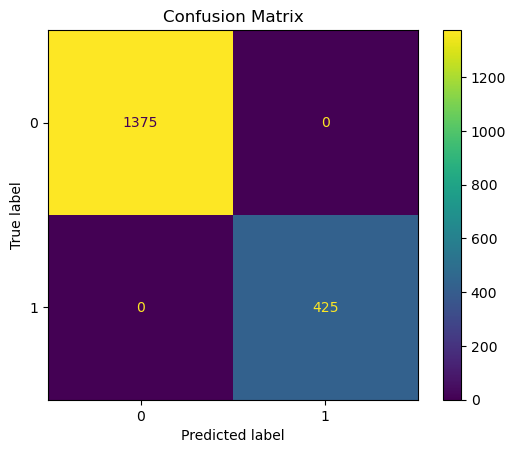

In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Confusion Matrix")
plt.show()

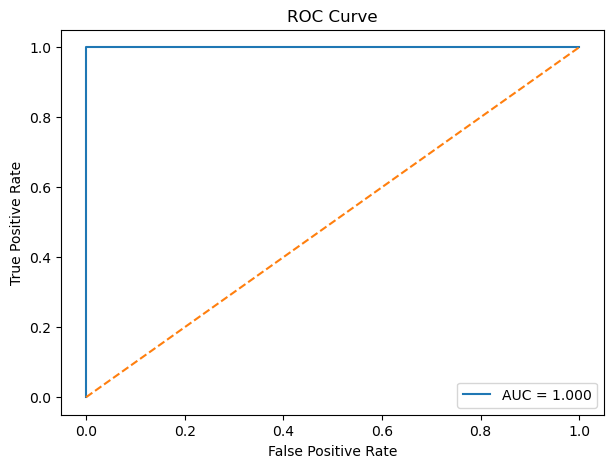

In [46]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

auc_score = roc_auc_score(
    y_test,
    y_prob
)


plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

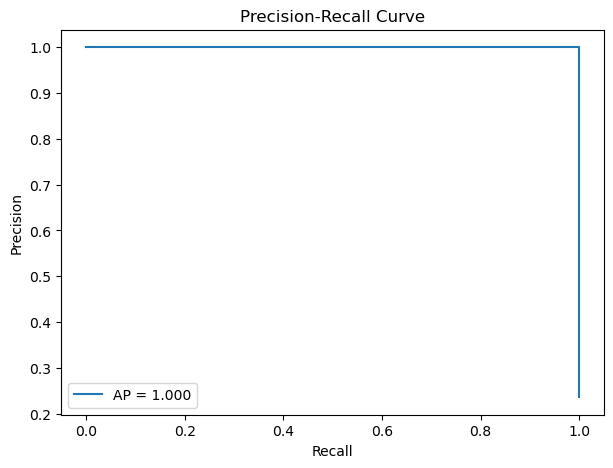

In [47]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

ap_score = average_precision_score(
    y_test,
    y_prob
)


plt.figure(figsize=(7,5))

plt.plot(
    recall,
    precision,
    label=f"AP = {ap_score:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.show()

In [48]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# تعريف الموديل
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

# القيم التي سيتم تجربتها
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',      # أو 'f1' إذا كان الأهم هو F1
    n_jobs=-1,
    verbose=1
)

# التدريب
grid_search.fit(x_train, y_train)

# أفضل باراميترز
print("Best Parameters:")
print(grid_search.best_params_)

# أفضل Accuracy أثناء الـ CV
print("Best CV Score:")
print(grid_search.best_score_)


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV Score:
1.0


In [49]:
best_xgb = grid_search.best_estimator_

y_pred = best_xgb.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 1.0
F1: 1.0
Recall: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1375
           1       1.00      1.00      1.00       425

    accuracy                           1.00      1800
   macro avg       1.00      1.00      1.00      1800
weighted avg       1.00      1.00      1.00      1800



In [51]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# ==========================================
# 1. تحميل البيانات
# ==========================================
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# تحديد عمود الهدف (Target) والميزات (Features)
X = train_df.drop(columns=['label', 'id'], errors='ignore')
y = train_df['label']

# ==========================================
# 2. تصنيف الأعمدة (Numerical & Categorical)
# ==========================================
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# ==========================================
# 3. بناء الخطوات المسبقة (Preprocessing)
# ==========================================
# معالجة البيانات الرقمية: تعويض القيم المفقودة بالمتوسط ثم عمل Scaling
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# معالجة البيانات النصية/الفئات (إن وجدت): تعويض المفقود ثم One-Hot Encoding
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# دمج معالجة الأعمدة معاً
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

# ==========================================
# 4. بناء الـ Pipeline الكامل مع الموديل
# ==========================================
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# ==========================================
# 5. تقسيم البيانات وتدريب الموديل
# ==========================================
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# تدريب الـ Pipeline بالكامل
full_pipeline.fit(X_train, y_train)

# تقييم الموديل على بيانات التحقق (Validation)
y_pred_val = full_pipeline.predict(X_val)
print("--- تقييم الموديل على Validation Set ---")
print(classification_report(y_val, y_pred_val))

# ==========================================
# 6. التنبؤ على بيانات الاختبار (test.csv) وحفظ النتائج
# ==========================================
# إعادة التدريب على كامل بيانات train للحصول على أفضل دقة قبل التنبؤ النهائي
full_pipeline.fit(X, y)

# التنبؤ المباشر بالـ Pipeline (بيطبق كل خطوات Preprocessing تلقائياً)
test_predictions = full_pipeline.predict(test_df.drop(columns=['id'], errors='ignore'))

# لو المسابقة تطلب الاحتمالات (Probabilities) بدلاً من 0/1، افعلي الآتي:
# test_predictions = full_pipeline.predict_proba(test_df.drop(columns=['id'], errors='ignore'))[:, 1]

# حفظ النتائج في ملف submission.csv
submission = pd.DataFrame({
    
    'label': test_predictions
})

submission.to_csv('submission.csv', index=False)
print("\nتم استخراج التنبؤات وحفظ ملف submission.csv بنجاح! 🚀")

--- تقييم الموديل على Validation Set ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1375
           1       1.00      1.00      1.00       425

    accuracy                           1.00      1800
   macro avg       1.00      1.00      1.00      1800
weighted avg       1.00      1.00      1.00      1800


تم استخراج التنبؤات وحفظ ملف submission.csv بنجاح! 🚀


In [52]:
import pandas as pd
import joblib
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# 1. تحميل البيانات
train_df = pd.read_csv('train.csv')

TARGET_COL = 'label'

X = train_df.drop(columns=[TARGET_COL], errors='ignore')
y = train_df[TARGET_COL]

# 2. تحديد أنواع الأعمدة
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# 3. بناء المعالجة والـ Pipeline
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])

# 4. التدريب على كامل البيانات
print("جاري تدريب النموذج...")
pipeline.fit(X, y)

# 5. حفظ النموذج والـ Schema في ملف
model_data = {
    'pipeline': pipeline,
    'num_cols': num_cols,
    'cat_cols': cat_cols
}
joblib.dump(model_data, 'exoplanet_model.pkl')
print("تم حفظ النموذج بنجاح في ملف exoplanet_model.pkl! 🚀")

جاري تدريب النموذج...
تم حفظ النموذج بنجاح في ملف exoplanet_model.pkl! 🚀


In [53]:
import pandas as pd
import joblib
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# 1. تحميل البيانات
train_df = pd.read_csv('train.csv')

ID_COL = 'star_id'
TARGET_COL = 'label'

X = train_df.drop(columns=[TARGET_COL, ID_COL], errors='ignore')
y = train_df[TARGET_COL]

# 2. تحديد أنواع الأعمدة
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# 3. بناء الـ Pipeline
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])

# 4. التدريب
print("جاري تدريب النموذج...")
pipeline.fit(X, y)

# 5. حفظ النموذج في ملف .pkl
model_data = {
    'pipeline': pipeline,
    'num_cols': num_cols,
    'cat_cols': cat_cols
}
joblib.dump(model_data, 'exoplanet_model.pkl')
print(" تم حفظ النموذج بنجاح في ملف exoplanet_model.pkl!")

جاري تدريب النموذج...
 تم حفظ النموذج بنجاح في ملف exoplanet_model.pkl!
